<a href="https://colab.research.google.com/github/Pooya-Moayed/Bachelors-Desertation/blob/Classification/Pooya_Project_Classification_Zone_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Loading Data**


In [ ]:
import pandas as pd

data = pd.read_excel('/content/drive/MyDrive/Project/Data - Class3.xlsx',index_col=None)

data.head()

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam,Class 3
0,191,241,238,236,249,8.2,8514,1321,45,3
1,194,240,235,234,251,8.2,7184,1158,45,4
2,194,241,233,234,249,8.2,8546,1350,50,5
3,194,242,242,234,250,8.7,8337,1427,50,1
4,195,239,239,237,250,8.3,8262,1409,45,2


In [ ]:
len(data)

269

# **2. Preparing Data**

In [ ]:
# Split into X and y

X = data.drop('Class 3', axis=1)
y = data['Class 3']

In [ ]:
X

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
0,191,241,238,236,249,8.2,8514,1321,45
1,194,240,235,234,251,8.2,7184,1158,45
2,194,241,233,234,249,8.2,8546,1350,50
3,194,242,242,234,250,8.7,8337,1427,50
4,195,239,239,237,250,8.3,8262,1409,45
...,...,...,...,...,...,...,...,...,...
264,195,233,236,237,251,7.9,8276,1388,50
265,183,233,230,232,252,7.9,7986,1331,45
266,183,233,237,233,251,7.9,7969,1384,45
267,188,231,241,237,250,9.3,8065,1288,40


In [ ]:
y

0      3
1      4
2      5
3      1
4      2
      ..
264    3
265    6
266    2
267    1
268    5
Name: Class 3, Length: 269, dtype: int64

In [ ]:
# Split data into training and test data

from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
115,194,239,239,238,252,7.50,8300,1435,40
33,192,242,238,241,250,8.10,8544,1471,40
180,191,239,241,238,250,7.70,8085,1270,45
141,190,236,235,235,251,7.40,8495,1445,40
248,187,235,238,238,249,7.90,8257,1350,45
...,...,...,...,...,...,...,...,...,...
20,196,241,238,235,249,8.40,8591,1299,50
188,191,239,234,237,249,7.75,8067,1325,35
71,194,238,236,236,249,7.90,8232,1312,35
106,186,237,238,239,250,7.50,8290,1335,40


In [ ]:
X_test

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
30,194,238,240,237,250,8.10,8374,1459,50
116,194,238,236,234,251,7.50,8460,1470,35
79,186,242,239,234,250,8.50,8481,1310,40
127,189,239,238,233,249,7.50,8377,1419,45
190,191,240,237,235,248,7.50,8322,1403,45
137,191,240,242,241,251,7.50,8258,1318,50
202,191,241,233,235,251,7.75,8271,1430,45
45,191,241,238,235,249,8.20,8314,1470,45
173,192,232,237,236,251,7.70,8251,1290,50
239,191,239,235,235,251,8.50,8135,1440,45


In [ ]:
y_train

115    1
33     3
180    1
141    5
248    2
      ..
20     3
188    4
71     3
106    2
102    2
Name: Class 3, Length: 215, dtype: int64

In [ ]:
y_test

30     2
116    4
79     2
127    2
190    3
137    1
202    5
45     2
173    3
239    3
179    2
267    1
220    1
82     1
186    3
185    3
241    4
265    6
104    4
60     3
261    6
184    1
46     3
42     1
181    1
9      6
22     2
193    1
109    3
24     1
113    3
68     1
143    1
217    2
197    4
6      3
120    1
67     1
119    4
118    5
25     3
125    3
165    1
19     5
77     1
209    5
90     1
170    6
93     3
258    4
15     3
150    4
224    4
242    3
Name: Class 3, dtype: int64

In [ ]:
y_test.value_counts()

1    16
3    15
4     8
2     7
5     4
6     4
Name: Class 3, dtype: int64

In [ ]:
y_train.value_counts()

1    69
3    43
4    37
2    30
5    25
6    11
Name: Class 3, dtype: int64

##Imbalanced Data

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE

smote = SMOTE(sampling_strategy='minority')
#smote = BorderlineSMOTE(sampling_strategy='not majority')


#Creating new samples by SMOTE sampling
X_sm, y_sm = smote.fit_resample(X,y)

from sklearn.model_selection import train_test_split
import numpy as np

#np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.1, stratify=y_sm)

In [ ]:
from imblearn.over_sampling import ADASYN

sm = ADASYN(sampling_strategy='not majority')
X_sm2, y_sm2 = sm.fit_resample(X, y)

from sklearn.model_selection import train_test_split
import numpy as np

#np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X_sm2, y_sm2, test_size=0.1, stratify=y_sm2)

##Pearson Correlation  (detecting highly correlated data)

<function matplotlib.pyplot.show(*args, **kw)>

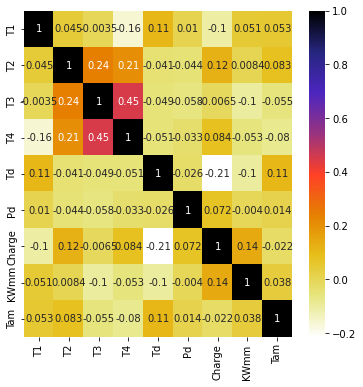

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Using Pearson Correlation
plt.figure(figsize=(6,6))
cor = X.corr(method='pearson')
#cor2 = X.corr(method='spearman')
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
#sns.heatmap(cor2, annot=True, cmap=plt.cm.CMRmap_r)
plt.show

# **3. Building Machine Learning Model**

## All Models

In [ ]:
!pip install catboost
!pip install logitboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 1.2 MB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Test the models
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from logitboost import LogitBoost


from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, jaccard_score, fbeta_score, hamming_loss, matthews_corrcoef, log_loss, f1_score, average_precision_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, cohen_kappa_score
from imblearn.metrics import sensitivity_score, specificity_score, geometric_mean_score
import numpy as np

# 3.1. Ridge Classification Model

In [ ]:
from sklearn.linear_model import RidgeClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
model = RidgeClassifier()
model.fit(X_train, y_train)

RidgeClassifier()

In [ ]:
#Evaluate our model
model.score(X_test, y_test)

0.4528301886792453

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([0.5       , 0.38888889, 0.44444444, 0.44444444, 0.49056604])

In [ ]:
y_preds = model.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.75       0.25       0.         0.         0.         0.        ]
 [0.55555556 0.44444444 0.         0.         0.         0.        ]
 [0.2        0.2        0.1        0.3        0.2        0.        ]
 [0.33333333 0.11111111 0.11111111 0.11111111 0.33333333 0.        ]
 [0.         0.         0.         0.         0.375      0.625     ]
 [0.         0.         0.         0.         0.         1.        ]]
              precision    recall  f1-score   support

           1       0.38      0.75      0.50         8
           2       0.44      0.44      0.44         9
           3       0.50      0.10      0.17        10
           4       0.25      0.11      0.15         9
           5       0.38      0.38      0.38         8
           6       0.64      1.00      0.78         9

    accuracy                           0.45        53
   macro avg       0.43      0.46      0.40        53
weighted avg       0.43      0.45      0.40        53



In [ ]:
#Use the trained model to make predictions

y_preds = model.predict(X_test)
#y_preds[:10]
y_preds

array([1, 2, 1, 3, 1, 1, 1, 1, 1, 6, 5, 1, 6, 4, 5, 6, 5, 2, 2, 2, 1, 1,
       5, 5, 1, 6, 5, 5, 2, 6, 2, 6, 6, 6, 1, 2, 4, 6, 2, 1, 3, 4, 6, 4,
       6, 1, 1, 6, 5, 6, 6, 2, 1])

In [ ]:
#y_test[:10]
y_test

18     3
227    2
286    2
197    4
173    3
359    4
276    2
87     1
14     1
520    6
110    4
366    4
510    6
134    3
421    5
461    6
450    5
253    3
319    2
56     2
275    2
1      4
164    4
338    3
82     1
460    6
111    3
445    5
212    1
487    6
228    1
230    5
474    6
406    5
282    2
190    3
69     3
452    5
83     4
189    1
327    3
381    4
152    5
206    3
265    6
106    2
57     1
471    6
393    4
476    6
417    5
284    2
263    1
Name: Class 3, dtype: int64

# 3.2. Random Forest Classification Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
rf = RandomForestClassifier(max_depth= 20,
 max_features= 'auto',
 min_samples_leaf= 1,
 min_samples_split= 8,
 n_estimators= 100)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=8)

In [ ]:
#Evaluate our model
rf.score(X_test, y_test)

0.8490566037735849

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, cv=5)

array([0.81481481, 0.7962963 , 0.87037037, 0.75925926, 0.71698113])

In [ ]:
y_preds = rf.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.75       0.25       0.         0.         0.         0.        ]
 [0.11111111 0.88888889 0.         0.         0.         0.        ]
 [0.         0.2        0.8        0.         0.         0.        ]
 [0.         0.11111111 0.         0.88888889 0.         0.        ]
 [0.         0.         0.         0.125      0.75       0.125     ]
 [0.         0.         0.         0.         0.         1.        ]]
              precision    recall  f1-score   support

           1       0.86      0.75      0.80         8
           2       0.62      0.89      0.73         9
           3       1.00      0.80      0.89        10
           4       0.89      0.89      0.89         9
           5       1.00      0.75      0.86         8
           6       0.90      1.00      0.95         9

    accuracy                           0.85        53
   macro avg       0.88      0.85      0.85        53
weighted avg       0.88      0.85      0.85        53



## 3.3. KNeighbours Classification Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
neigh = KNeighborsClassifier(n_neighbors = 50)
neigh.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=50)

In [ ]:
#Evaluate our model
neigh.score(X_test, y_test)

0.2641509433962264

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(neigh, X, y, cv=5)

array([0.38888889, 0.27777778, 0.33333333, 0.31481481, 0.28301887])

In [ ]:
y_preds = neigh.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.125      0.125      0.375      0.125      0.125      0.125     ]
 [0.22222222 0.22222222 0.         0.22222222 0.         0.33333333]
 [0.2        0.1        0.2        0.2        0.2        0.1       ]
 [0.22222222 0.         0.22222222 0.11111111 0.11111111 0.33333333]
 [0.         0.125      0.25       0.         0.5        0.125     ]
 [0.11111111 0.         0.22222222 0.22222222 0.         0.44444444]]
              precision    recall  f1-score   support

           1       0.12      0.12      0.12         8
           2       0.40      0.22      0.29         9
           3       0.18      0.20      0.19        10
           4       0.12      0.11      0.12         9
           5       0.50      0.50      0.50         8
           6       0.31      0.44      0.36         9

    accuracy                           0.26        53
   macro avg       0.27      0.27      0.26        53
weighted avg       0.27      0.26      0.26        53



# 3.4. DecisionTree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
#Evaluate our model
dt.score(X_test, y_test)

0.8490566037735849

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(dt, X, y, cv=5)

array([0.72222222, 0.87037037, 0.7962963 , 0.75925926, 0.66037736])

In [ ]:
y_preds = dt.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.75       0.25       0.         0.         0.         0.        ]
 [0.11111111 0.88888889 0.         0.         0.         0.        ]
 [0.         0.1        0.9        0.         0.         0.        ]
 [0.         0.11111111 0.11111111 0.77777778 0.         0.        ]
 [0.         0.         0.         0.125      0.75       0.125     ]
 [0.         0.         0.         0.         0.         1.        ]]
              precision    recall  f1-score   support

           1       0.86      0.75      0.80         8
           2       0.67      0.89      0.76         9
           3       0.90      0.90      0.90        10
           4       0.88      0.78      0.82         9
           5       1.00      0.75      0.86         8
           6       0.90      1.00      0.95         9

    accuracy                           0.85        53
   macro avg       0.87      0.84      0.85        53
weighted avg       0.86      0.85      0.85        53



# 3.5. SVM (Support Vector Machine)

In [ ]:
from sklearn import svm
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
svr = svm.SVC()
svr.fit(X_train,y_train)

SVC()

In [ ]:
#Evaluate our model
svr.score(X_test, y_test)

0.18867924528301888

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(svr, X, y, cv=5)

array([0.31481481, 0.31481481, 0.31481481, 0.31481481, 0.32075472])

In [ ]:
y_preds = svr.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         9
           3       0.19      1.00      0.32        10
           4       0.00      0.00      0.00         9
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00         9

    accuracy                           0.19        53
   macro avg       0.03      0.17      0.05        53
weighted avg       0.04      0.19      0.06        53



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# 3.6. XGBOOST

In [ ]:
from xgboost import XGBClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
xgb = XGBClassifier( max_depth=50, learning_rate=0.1, n_estimators=100)
xgb.fit(X_train,y_train)

XGBClassifier(max_depth=50, objective='multi:softprob')

In [ ]:
#Evaluate our model
xgb.score(X_test, y_test)

0.8679245283018868

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(xgb, X, y, cv=5)

array([0.7962963 , 0.83333333, 0.87037037, 0.81481481, 0.81132075])

In [ ]:
y_preds = xgb.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.75       0.         0.         0.25       0.         0.        ]
 [0.11111111 0.88888889 0.         0.         0.         0.        ]
 [0.         0.1        0.9        0.         0.         0.        ]
 [0.         0.11111111 0.11111111 0.77777778 0.         0.        ]
 [0.         0.         0.         0.125      0.875      0.        ]
 [0.         0.         0.         0.         0.         1.        ]]
              precision    recall  f1-score   support

           1       0.86      0.75      0.80         8
           2       0.80      0.89      0.84         9
           3       0.90      0.90      0.90        10
           4       0.70      0.78      0.74         9
           5       1.00      0.88      0.93         8
           6       1.00      1.00      1.00         9

    accuracy                           0.87        53
   macro avg       0.88      0.87      0.87        53
weighted avg       0.87      0.87      0.87        53



#3.7. CATBOOST

In [ ]:
from catboost import CatBoostClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
catb =  CatBoostClassifier(iterations=100, learning_rate = 1.0, objective='MultiClass')
catb.fit(X_train,y_train)

0:	learn: 0.9705150	total: 62ms	remaining: 6.14s
1:	learn: 0.7387570	total: 73.6ms	remaining: 3.6s
2:	learn: 0.5918005	total: 84ms	remaining: 2.72s
3:	learn: 0.4452569	total: 89.2ms	remaining: 2.14s
4:	learn: 0.3974396	total: 93.3ms	remaining: 1.77s
5:	learn: 0.3464357	total: 97.5ms	remaining: 1.53s
6:	learn: 0.3161339	total: 101ms	remaining: 1.35s
7:	learn: 0.2905328	total: 106ms	remaining: 1.21s
8:	learn: 0.2643967	total: 110ms	remaining: 1.11s
9:	learn: 0.2355034	total: 114ms	remaining: 1.03s
10:	learn: 0.2127258	total: 118ms	remaining: 957ms
11:	learn: 0.2000134	total: 122ms	remaining: 898ms
12:	learn: 0.1910582	total: 127ms	remaining: 852ms
13:	learn: 0.1761601	total: 132ms	remaining: 809ms
14:	learn: 0.1715049	total: 136ms	remaining: 771ms
15:	learn: 0.1547965	total: 143ms	remaining: 753ms
16:	learn: 0.1495727	total: 148ms	remaining: 723ms
17:	learn: 0.1426639	total: 152ms	remaining: 694ms
18:	learn: 0.1293022	total: 157ms	remaining: 668ms
19:	learn: 0.1197963	total: 161ms	remain

In [ ]:
#Evaluate our model
catb.score(X_test, y_test)

0.8867924528301887

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(catb, X, y, cv=5)

0:	learn: 1.2180871	total: 3.31ms	remaining: 328ms
1:	learn: 0.9708206	total: 6.28ms	remaining: 308ms
2:	learn: 0.7015510	total: 8.68ms	remaining: 281ms
3:	learn: 0.5774673	total: 11.5ms	remaining: 275ms
4:	learn: 0.5000091	total: 13.9ms	remaining: 265ms
5:	learn: 0.4564966	total: 16.3ms	remaining: 255ms
6:	learn: 0.4205808	total: 18.7ms	remaining: 248ms
7:	learn: 0.3790513	total: 21ms	remaining: 242ms
8:	learn: 0.3215947	total: 23.5ms	remaining: 238ms
9:	learn: 0.2875040	total: 26.3ms	remaining: 237ms
10:	learn: 0.2660506	total: 29.9ms	remaining: 242ms
11:	learn: 0.2493108	total: 32.6ms	remaining: 239ms
12:	learn: 0.2314307	total: 35ms	remaining: 234ms
13:	learn: 0.2226064	total: 37.4ms	remaining: 230ms
14:	learn: 0.2021150	total: 39.7ms	remaining: 225ms
15:	learn: 0.1892398	total: 42.1ms	remaining: 221ms
16:	learn: 0.1800394	total: 44.4ms	remaining: 217ms
17:	learn: 0.1657890	total: 46.8ms	remaining: 213ms
18:	learn: 0.1506568	total: 49.1ms	remaining: 209ms
19:	learn: 0.1405952	total

array([0.7962963 , 0.77777778, 0.77777778, 0.81481481, 0.67924528])

In [ ]:
y_preds = catb.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[0.875      0.125      0.         0.         0.         0.        ]
 [0.11111111 0.88888889 0.         0.         0.         0.        ]
 [0.         0.1        0.9        0.         0.         0.        ]
 [0.         0.         0.22222222 0.77777778 0.         0.        ]
 [0.         0.         0.         0.125      0.875      0.        ]
 [0.         0.         0.         0.         0.         1.        ]]
              precision    recall  f1-score   support

           1       0.88      0.88      0.88         8
           2       0.80      0.89      0.84         9
           3       0.82      0.90      0.86        10
           4       0.88      0.78      0.82         9
           5       1.00      0.88      0.93         8
           6       1.00      1.00      1.00         9

    accuracy                           0.89        53
   macro avg       0.89      0.89      0.89        53
weighted avg       0.89      0.89      0.89        53



##Results

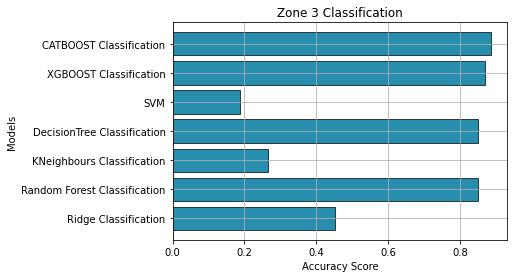

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_valeues=['Ridge Classification', 'Random Forest Classification', 'KNeighbours Classification',
           'DecisionTree Classification', 'SVM', 'XGBOOST Classification', 'CATBOOST Classification']

y_valeues=[model.score(X_test, y_test), rf.score(X_test, y_test), neigh.score(X_test, y_test), dt.score(X_test, y_test),
           svr.score(X_test, y_test), xgb.score(X_test, y_test), catb.score(X_test, y_test)]

# plot
plt.barh(x_valeues, y_valeues, color='#288ead', edgecolor="black", linewidth=0.7)

plt.xlabel('Accuracy Score')
plt.ylabel('Models')
plt.title('Zone 3 Classification')
plt.grid(True)

plt.show()